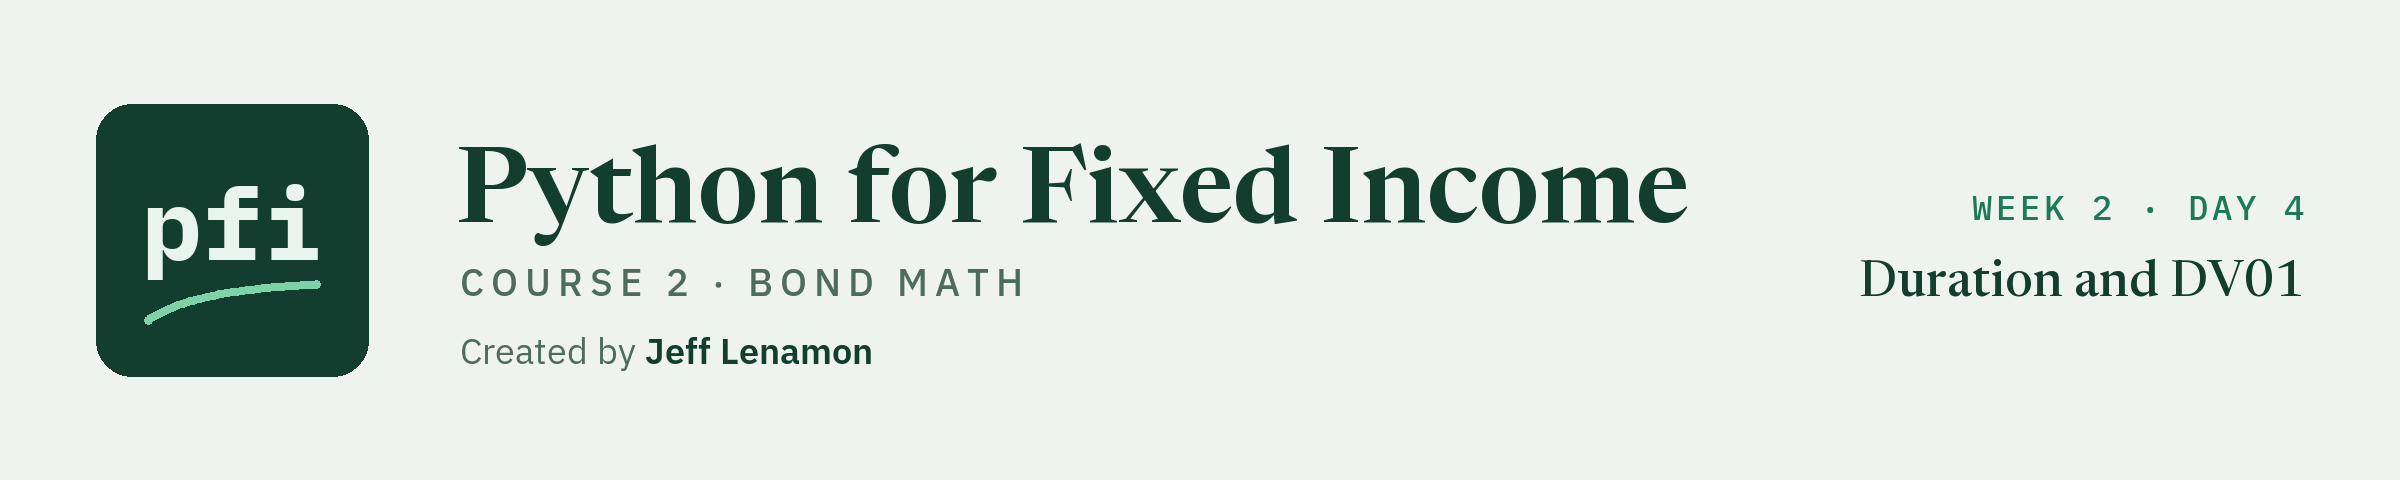

# Duration and DV01

Week 2, Day 4. How far does a price move when the yield moves? Macaulay duration as the average time of a bond's cash flows, modified duration as price sensitivity, and DV01 per 100 and per position, each checked against Excel, then the duration column of the holdings file reproduced for all 200 bonds.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week2/day4/09_duration_and_dv01.ipynb)

Day 8 priced the four bonds on Monday 30 November 2026: the clean price a desk quotes, the dirty price an invoice pays, and the yield back from a price. A portfolio manager's next question is about change, not level: **if yields move one basis point, how much does each position make or lose, in dollars?**

Today you will:

1. Find Quorvane's **Macaulay duration**, the present-value weighted average time of its cash flows, by hand and then as a function.
2. Turn it into **modified duration**, the percent change in price for a change in yield, and see how far that straight line reaches.
3. Compute **DV01**: price points per 100 of face for one basis point, then dollars for each position and for the book.
4. Check DV01 a second way, by **bumping the yield** one basis point either side and repricing.
5. Get the **signs** right: what a positive DV01 means for a long position, and what changes for a short one.
6. Reproduce the **duration column** of the holdings file for all 200 bonds.

The issuers are invented, the positions are invented, and so is every number. Nothing here says a bond is good or bad, or where yields will go.

The setup cell is the same as every day. The next cell writes `bondmath.py` and `test_bondmath.py` as they stood at the end of day 8.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_09_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_09_zjneqeua, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier


def test_add_months_clamps_to_month_end():
    # 31 August back 6 months: 28 February, or 29 February in a leap year
    assert bondmath.add_months(date(2031, 8, 31), -6) == date(2031, 2, 28)
    assert bondmath.add_months(date(2032, 8, 31), -6) == date(2032, 2, 29)
    # 31 January forward 1 month
    assert bondmath.add_months(date(2027, 1, 31), 1) == date(2027, 2, 28)
    # a day every month has is kept, across a year end
    assert bondmath.add_months(date(2026, 11, 15), 3) == date(2027, 2, 15)


def test_coupon_dates_match_excel():
    for row in REFERENCE:
        settlement, maturity = date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"])
        dates = bondmath.coupon_dates(settlement, maturity, int(row["frequency"]))
        # [0] is COUPPCD, [1] is COUPNCD, and the number of dates after [0] is COUPNUM
        assert dates[0] == date.fromisoformat(row["couppcd"]), row["case_id"]
        assert dates[1] == date.fromisoformat(row["coupncd"]), row["case_id"]
        assert len(dates) - 1 == int(row["coupnum"]), row["case_id"]


BASIS = {"0": "30/360", "1": "ACT/ACT"}  # Excel's basis number to bondmath's name


def bond_inputs(row: dict) -> tuple:
    """settlement, maturity, coupon_pct, yield_pct, frequency, basis from a reference row, in bondmath's units."""
    return (date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"]),
            float(row["coupon_pct"]), float(row["yield_pct"]), int(row["frequency"]), BASIS[row["basis"]])


def test_days_30_360_rule_cases():
    # (start, end, expected days, the Excel function that confirms the value)
    cases = [
        (date(2026, 8, 16), date(2026, 9, 30), 44, "COUPDAYBS"),    # no rule applies
        (date(2027, 2, 28), date(2027, 3, 1), 1, "COUPDAYBS"),      # rule 1: last day of February counts as 30
        (date(2027, 2, 28), date(2028, 2, 29), 360, "YEARFRAC"),    # rule 2: both on the last day of February
        (date(2026, 8, 31), date(2026, 9, 30), 30, "COUPDAYBS"),    # rule 3: a 31st start counts as 30
        (date(2026, 7, 30), date(2026, 10, 31), 90, "COUPDAYBS"),   # rule 4: a 31st end after a 30th start
        (date(2026, 10, 15), date(2026, 10, 31), 16, "COUPDAYBS"),  # a 31st end after a 15th start stays 31
        (date(2027, 2, 28), date(2027, 3, 31), 31, "COUPDAYBS"),    # rule 1, and the 31st end stays 31
        (date(2026, 11, 15), date(2027, 2, 28), 103, "COUPDAYBS"),  # an end on 28 February is not changed
    ]
    for start, end, expected, source in cases:
        assert bondmath.days_30_360(start, end) == expected, (start, end)
        if source == "COUPDAYBS":
            # the same pair of dates appears in the reference file as previous coupon and settlement
            matches = [row for row in REFERENCE if row["basis"] == "0" and row["couppcd"] == start.isoformat()
                       and row["settlement"] == end.isoformat()]
            assert matches, f"no reference row with previous coupon {start} and settlement {end}"
            assert int(matches[0]["coupdaybs"]) == expected
        # the YEARFRAC value, YEARFRAC(start, end, 0) x 360 = 360, was checked in Excel by the reference tool


def test_coupon_period_days_match_excel():
    for row in REFERENCE:
        settlement, maturity, _, _, frequency, basis = bond_inputs(row)
        days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, maturity, frequency, basis)
        # A is COUPDAYBS under both bases
        assert days_accrued == int(row["coupdaybs"]), row["case_id"]
        if basis == "30/360":
            # E is COUPDAYS, and PRICE uses DSC = E - A
            assert days_in_period == int(row["coupdays"]), row["case_id"]
            assert days_to_next == int(row["coupdays"]) - int(row["coupdaybs"]), row["case_id"]
        else:
            # E is the actual length of the period, which PRICE uses (Excel's COUPDAYS with basis 1 can differ)
            period_start, period_end = date.fromisoformat(row["couppcd"]), date.fromisoformat(row["coupncd"])
            assert days_in_period == (period_end - period_start).days, row["case_id"]
            assert days_to_next == int(row["coupdaysnc"]), row["case_id"]


def test_accrued_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        result = bondmath.accrued_interest(settlement, maturity, coupon_pct, frequency, basis)
        assert result == pytest.approx(float(row["accrued"]), abs=1e-9), row["case_id"]


def test_price_matches_excel():
    for row in REFERENCE:
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_dirty_is_clean_plus_accrued():
    for row in REFERENCE:
        result = bondmath.dirty_price(*bond_inputs(row))
        # Excel's PRICE plus Excel's accrued formula
        assert result == pytest.approx(float(row["price"]) + float(row["accrued"]), abs=1e-6), row["case_id"]


def test_price_on_coupon_date_equals_week1():
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        settlement, maturity, coupon_pct, yield_pct, frequency, basis = bond_inputs(row)
        # on a coupon date the bond has a whole number of periods left
        years = int(row["coupnum"]) / frequency
        week1_price = bondmath.price_from_yield(coupon_pct, yield_pct, years, frequency)
        assert bondmath.price(settlement, maturity, coupon_pct, yield_pct, frequency, basis) == pytest.approx(
            week1_price, abs=1e-9), row["case_id"]


def test_final_period_matches_excel():
    final_period_rows = [row for row in REFERENCE if row["coupnum"] == "1"]
    assert final_period_rows, "no final-period rows in the reference file"
    for row in final_period_rows:
        # one coupon left: Excel prices it with simple interest
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_yield_to_maturity_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        # solve the yield from Excel's price, and compare with Excel's YIELD of that price
        result = bondmath.yield_to_maturity(settlement, maturity, coupon_pct, float(row["price"]), frequency, basis)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price', 'add_months', 'coupon_dates', 'days_30_360', 'coupon_period_days', 'accrued_interest', 'price', 'dirty_price', 'yield_to_maturity']


* The two files exactly as day 8 left them: 14 functions and 23 tests. By the end of today there will be 17 functions and 27 tests.

Record the starting point in Git first.

Q. Make the work folder a repository and commit the start-of-day files.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_09_zjneqeua and nowhere else


In [7]:
# choose the two files, commit them quietly, and show the history
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Start of day 9: bondmath.py and test_bondmath.py as day 8 left them"
!git -C "{work}" log --oneline

957fc63 Start of day 9: bondmath.py and test_bondmath.py as day 8 left them


* One commit, the start of day 9.

Q. Type in the four bonds, with a position in each.

In [8]:
from datetime import date

bonds = pd.DataFrame({
    "cusip": ['99001BZA7', '99002CZA4', '99003DZA1', '99004EZA8'],
    "issuer": ['Quorvane Energy', 'Dunmarrow Rail', 'Pellwick Paper', 'Halvering Foods'],
    "ticker": ['QVNE', 'DNMR', 'PLWK', 'HLVF'],
    "coupon_pct": [5.25, 6.125, 4.75, 7.5],
    "maturity": [date.fromisoformat(text) for text in ['2031-09-30', '2033-09-30', '2029-09-30', '2036-09-30']],
    "yield_pct": [5.4, 6.125, 4.6, 7.7],
    # face value held, in dollars (invented positions); the underscores only make the digits easy to read
    "par_held": [5_000_000, 3_000_000, 4_000_000, 2_000_000],
})
settlement = date(2026, 11, 30)

bonds

,cusip,issuer,ticker,coupon_pct,maturity,yield_pct,par_held
0,99001BZA7,Quorvane Energy,QVNE,5.250,2031-09-30,5.400,5000000
1,99002CZA4,Dunmarrow Rail,DNMR,6.125,2033-09-30,6.125,3000000
2,99003DZA1,Pellwick Paper,PLWK,4.750,2029-09-30,4.600,4000000
3,99004EZA8,Halvering Foods,HLVF,7.500,2036-09-30,7.700,2000000


* The same four bonds and yields as all week, now with a `par_held` column: the face value of each position, in dollars. The positions are invented for the lesson.

Q. Day 8's three numbers for each bond on 30 November: clean price, accrued, and dirty price.

In [9]:
# day 8's functions, one bond at a time
bonds["clean"] = [bondmath.price(settlement, m, c, y) for m, c, y in zip(bonds["maturity"], bonds["coupon_pct"], bonds["yield_pct"])]
bonds["accrued"] = [bondmath.accrued_interest(settlement, m, c) for m, c in zip(bonds["maturity"], bonds["coupon_pct"])]
bonds["dirty"] = bonds["clean"] + bonds["accrued"]
bonds[["issuer", "yield_pct", "clean", "accrued", "dirty"]].round(6)

,issuer,yield_pct,clean,accrued,dirty
0,Quorvane Energy,5.400,99.361551,0.875000,100.236551
1,Dunmarrow Rail,6.125,99.989753,1.020833,101.010586
2,Pellwick Paper,4.600,100.388247,0.791667,101.179914
3,Halvering Foods,7.700,98.622491,1.250000,99.872491


* Quorvane's dirty price is 100.236551 per 100: 99.361551 clean plus 0.875 accrued. Today every sensitivity is measured on the **dirty** price, because that is what the position is worth.

## 9.1 Macaulay Duration: the Average Time of the Cash Flows

A bond is a set of payments at different times. Quorvane pays 10 coupons and its face between now and 30 September 2031. Which single number of years sums that up? Maturity is one answer, but it ignores every coupon. **Macaulay duration** takes the average of the payment times, each weighted by its share of the price: the present value of that payment divided by the sum of all the present values, the dirty price.

Q. List Quorvane's cash flows on 30 November, with the time of each in years and its present value.

In [10]:
quorvane = bonds.set_index("ticker").loc["QVNE"]
dates = bondmath.coupon_dates(settlement, quorvane["maturity"])
days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, quorvane["maturity"])

# day 8's w: the part of a period left until the next coupon
w = days_to_next / days_in_period
period_yield = quorvane["yield_pct"] / 100 / 2

rows = []
for k, pay_date in enumerate(dates[1:]):
    # a coupon each half year, and the face with the last one
    cash_flow = quorvane["coupon_pct"] / 2 + (100 if pay_date == quorvane["maturity"] else 0)
    # the time in years: w + k periods, two periods a year
    time_years = (w + k) / 2
    pv = cash_flow / (1 + period_yield) ** (w + k)
    rows.append({"pay_date": pay_date, "time_years": time_years, "cash_flow": cash_flow, "pv": pv})

flows = pd.DataFrame(rows)
# each payment's share of the price
flows["weight"] = flows["pv"] / flows["pv"].sum()
print(f"w = {w:.6f}, sum of present values {flows['pv'].sum():.6f}, dirty price {quorvane['dirty']:.6f} per 100")
flows.round(6)

w = 0.666667, sum of present values 100.236551, dirty price 100.236551 per 100


,pay_date,time_years,cash_flow,pv,weight
0,2027-03-31,0.333333,2.625,2.578788,0.025727
1,2027-09-30,0.833333,2.625,2.510991,0.025051
2,2028-03-31,1.333333,2.625,2.444977,0.024392
3,2028-09-30,1.833333,2.625,2.380698,0.023751
4,2029-03-31,2.333333,2.625,2.318109,0.023126
5,2029-09-30,2.833333,2.625,2.257166,0.022518
6,2030-03-31,3.333333,2.625,2.197825,0.021926
7,2030-09-30,3.833333,2.625,2.140043,0.021350
8,2031-03-31,4.333333,2.625,2.083781,0.020789
9,2031-09-30,4.833333,102.625,79.324172,0.791370


* w = 120 / 180 = 0.666667: the first coupon is 0.666667 of a period, 0.333333 years, away. Every later payment is half a year after the one before.
* The present values add up to the dirty price, as on day 8, so the weights add up to 1. The last payment, coupon plus face, carries 79.1% of the weight.

Q. The weighted average time: Quorvane's Macaulay duration, by hand.

In [11]:
# each time multiplied by its weight, then added up
macaulay_by_hand = (flows["time_years"] * flows["weight"]).sum()
final_payment_years = flows["time_years"].iloc[-1]

print(f"Macaulay duration: {macaulay_by_hand:.6f} years")
print(f"time to the final payment: {final_payment_years:.6f} years")

Macaulay duration: 4.293248 years
time to the final payment: 4.833333 years


* 4.293248 years, where the final payment is 4.833333 years away. The coupons arrive earlier, so they pull the average in.

Q. Draw the present values on a time line, with the duration marked.

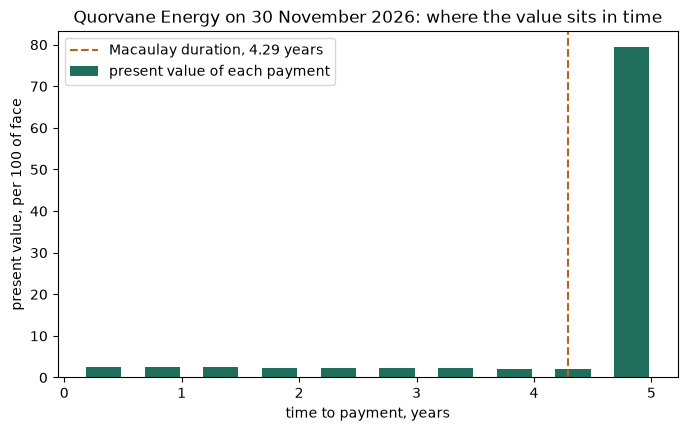

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
# one bar per payment: its present value per 100 at its time in years
ax.bar(flows["time_years"], flows["pv"], width=0.3, color="#1f6f5c", label="present value of each payment")
# the duration is the balance point of the bars
ax.axvline(macaulay_by_hand, color="#b5651d", linestyle="--", label=f"Macaulay duration, {macaulay_by_hand:.2f} years")
ax.set_title("Quorvane Energy on 30 November 2026: where the value sits in time")
ax.set_xlabel("time to payment, years")
ax.set_ylabel("present value, per 100 of face")
ax.legend()
plt.show()

* Picture the bars as weights on a ruler: Macaulay duration is the point where the ruler balances. The face, at the far end, is the heavy weight; 9 small coupons sit between.

> **Story: maturity is only one factor.** The idea and the name come from Frederick R. Macaulay's 1938 study for the National Bureau of Economic Research, *Some Theoretical Problems Suggested by the Movements of Interest Rates, Bond Yields and Stock Prices in the United States since 1856*. In its second chapter, "The Concept of Long Term Interest Rates", he argues that years to maturity is a poor measure of how long a loan really is, because maturity is the date of the last payment only: "'Duration' is a reality of which 'maturity' is only one factor" (page 45). He then weights the time of each payment by its present value, divided by the sum of all the present values, "which is, of course, the price paid for the bond" (page 48). That is the calculation in the cell above. Source: NBER, https://www.nber.org/books-and-chapters/some-theoretical-problems-suggested-movements-interest-rates-bond-yields-and-stock-prices-united/concept-long-term-interest-rates (chapter PDF read 2026-10-04).

Now the function. As every day this week, the docstring comes first: it is the specification. This is what `macaulay_duration` will promise:

```
Macaulay duration in years: the present-value weighted average time of the cash flows.

Units: coupon_pct and yield_pct in percent a year; the result is in years.
Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
```

Q. Write the test first, from Excel's `DURATION` column in the reference file.

In [13]:
%%writefile -a test_bondmath.py


def test_macaulay_matches_excel_duration():
    for row in REFERENCE:
        result = bondmath.macaulay_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["duration"]), abs=1e-6), row["case_id"]

Appending to test_bondmath.py


* One loop over every row of the reference file: the 200 holdings bonds, the edge cases, both bases, frequencies 1, 2, and 4, and this week's rows. `bond_inputs` has turned a row into the function's six arguments since day 7.

Q. Run the tests now, before the function exists.

In [14]:
# the new test should fail: bondmath has no macaulay_duration yet
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.......................F                                                 [100%]
================================== FAILURES ===================================
____________________ test_macaulay_matches_excel_duration _____________________

    def test_macaulay_matches_excel_duration():
        for row in REFERENCE:
>           result = bondmath.macaulay_duration(*bond_inputs(row))
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^
E           AttributeError: module 'bondmath' has no attribute 'macaulay_duration'

test_bondmath.py:281: AttributeError
=========================== short test summary info ===========================
FAILED test_bondmath.py::test_macaulay_matches_excel_duration - AttributeError: module 'bondmath' has no attribute 'macaulay_duration'
1 failed, 23 passed in 1.36s



* `1 failed, 23 passed`. The failure is the one we wanted: `AttributeError: module 'bondmath' has no attribute 'macaulay_duration'`. A test that has never failed has never proved anything; this one now has.

Q. Add `macaulay_duration` to the end of `bondmath.py`. Read it before you run the cell.

In [15]:
%%writefile -a bondmath.py


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv

Appending to bondmath.py


* The same steps as the cell by hand: the coupon dates and day counts (which also check the frequency, the basis, and the dates), w, one loop over the payments, and the weighted time divided by the total present value.
* There is no final-period branch. With one payment left, the loop runs once and the answer is that payment's time, DSC / E / frequency, which is what Excel returns.

Q. Reload the module, and compare the function with the cell by hand and with Excel's `DURATION` for all four bonds.

In [16]:
importlib.reload(bondmath)

# the function against the cell by hand
assert abs(bondmath.macaulay_duration(settlement, quorvane["maturity"], quorvane["coupon_pct"], quorvane["yield_pct"]) - macaulay_by_hand) < 1e-12

reference = pd.read_csv("bondmath_excel_reference.csv")
# the week 2 rows: the week 1 bonds settled on 30 November 2026, case_id the CUSIP
week2 = reference[reference["group"] == "week2"].set_index("case_id")

bonds["macaulay"] = [bondmath.macaulay_duration(settlement, m, c, y)
                     for m, c, y in zip(bonds["maturity"], bonds["coupon_pct"], bonds["yield_pct"])]
bonds["excel_duration"] = week2.loc[bonds["cusip"], "duration"].to_numpy()
assert (bonds["macaulay"] - bonds["excel_duration"]).abs().max() < 1e-6, "a duration differs from Excel"
bonds[["issuer", "coupon_pct", "maturity", "macaulay", "excel_duration"]]

,issuer,coupon_pct,maturity,macaulay,excel_duration
0,Quorvane Energy,5.250,2031-09-30,4.293248,4.293248
1,Dunmarrow Rail,6.125,2033-09-30,5.629619,5.629619
2,Pellwick Paper,4.750,2029-09-30,2.665045,2.665045
3,Halvering Foods,7.500,2036-09-30,7.020017,7.020017


* All four agree with Excel. Pellwick, maturing in 2029, has the shortest duration, 2.6650 years; Halvering, maturing in 2036, the longest, 7.0200. Halvering's duration is far shorter than its 9.83 years to maturity: a 7.5 percent coupon brings a lot of value forward.

**Excel side by side: `DURATION`.** Excel's function takes the arguments in the same order as `macaulay_duration`, with the coupon and the yield as decimals. Tested in Excel: `=DURATION(DATE(2026,11,30),DATE(2031,9,30),5.25/100,5.4/100,2,0)` returns 4.293247884617173, Quorvane's `duration` in the reference file. The last two arguments are the frequency, 2, and the basis, 0 for 30/360.

Q. A zero coupon bond makes one payment. What is its Macaulay duration?

In [17]:
# Quorvane's dates and yield, with no coupon
zero_duration = bondmath.macaulay_duration(settlement, quorvane["maturity"], 0.0, quorvane["yield_pct"])
print(f"zero coupon: {zero_duration:.6f} years; time to its one payment: {final_payment_years:.6f} years")

zero coupon: 4.833333 years; time to its one payment: 4.833333 years


* The same number. With one payment, all the weight sits on it, so the duration is the time to that payment. Excel agrees, tested: `=DURATION(DATE(2026,11,30),DATE(2031,9,30),0,5.4/100,2,0)` returns 4.833333333333333.
* So a coupon bond's duration is always shorter than its time to maturity, and a zero's is equal to it.

Q. Run the tests.

In [18]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

........................                                                 [100%]
24 passed in 1.07s



* `24 passed`. Every row of the reference file agrees with `DURATION` within 1e-6 years.

## 9.2 Modified Duration: Price Sensitivity

Macaulay duration is a time, in years. A desk wants something else: **how much does the price move when the yield moves?** Take the dirty price as a function of the yield and ask for its slope. Each payment's present value falls by its time, divided by (1 + y/2), for each unit of yield. Add them up and the slope of the price, as a share of the price, is

**modified duration = Macaulay duration / (1 + y / 2)**,

with y the yield as a decimal and 2 the coupons a year. Read it as: the price falls by about modified duration percent for each 1 percentage point (100 bp) rise in the yield, and by modified duration times 0.0001, as a share, for each basis point.

Q. Quorvane's modified duration by hand, and a test of what it claims: reprice at a yield 1 basis point higher.

In [19]:
modified_by_hand = macaulay_by_hand / (1 + quorvane["yield_pct"] / 100 / 2)

# day 8's dirty_price at the yield and at the yield + 0.01 percent (one basis point)
dirty_now = bondmath.dirty_price(settlement, quorvane["maturity"], quorvane["coupon_pct"], quorvane["yield_pct"])
dirty_up = bondmath.dirty_price(settlement, quorvane["maturity"], quorvane["coupon_pct"], quorvane["yield_pct"] + 0.01)

actual_pct = (dirty_up / dirty_now - 1) * 100
# modified duration times the change in yield as a decimal, as a percent
estimate_pct = -modified_by_hand * 0.0001 * 100
print(f"modified duration: {modified_by_hand:.6f}")
print(f"price change for +1 bp, repriced:          {actual_pct:.8f} percent")
print(f"price change for +1 bp, modified duration: {estimate_pct:.8f} percent")

modified duration: 4.180378
price change for +1 bp, repriced:          -0.04179333 percent
price change for +1 bp, modified duration: -0.04180378 percent


* Modified duration 4.180378: a 1 bp rise takes about 0.0418 percent off the price. The full reprice says -0.04179333 percent; the estimate -0.04180378. The gap is 1.0e-05 percent of the price.

Q. And for a move of 100 basis points, up and down?

In [20]:
for shift_pct in (1.0, -1.0):
    repriced = bondmath.dirty_price(settlement, quorvane["maturity"], quorvane["coupon_pct"], quorvane["yield_pct"] + shift_pct)
    # the straight line: minus modified duration x the shift as a decimal x the price
    estimate = -modified_by_hand * shift_pct / 100 * dirty_now
    print(f"yield {shift_pct * 100:+.0f} bp: repriced {repriced - dirty_now:+.6f}, duration estimate {estimate:+.6f}, "
          f"gap {repriced - dirty_now - estimate:+.6f} per 100")

yield +100 bp: repriced -4.087492, duration estimate -4.190266, gap +0.102775 per 100
yield -100 bp: repriced +4.296930, duration estimate +4.190266, gap +0.106664 per 100


* For 100 bp up, the price falls 4.0875 where the straight line says 4.1903; for 100 bp down it rises 4.2969, not 4.1903. Both gaps are on the same side: the real price is **above** the straight line either way.
* Duration is the slope at today's yield. The price-yield curve of day 3 bends, so a straight line drifts away from it for a large move. Tomorrow, day 10, measures that bend: convexity.

The docstring of the second function:

```
Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

Units: coupon_pct and yield_pct in percent a year; the result is in years.
Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
```

Q. The test, then the function.

In [21]:
%%writefile -a test_bondmath.py


def test_modified_matches_excel_mduration():
    for row in REFERENCE:
        result = bondmath.modified_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["mduration"]), abs=1e-6), row["case_id"]

Appending to test_bondmath.py


In [22]:
%%writefile -a bondmath.py


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)

Appending to bondmath.py


* The test reads `mduration`, Excel's `MDURATION`, from every row. The function is two lines: the period yield, and Macaulay duration divided by one plus it. It reuses `macaulay_duration` instead of repeating the loop.

Q. Reload, and compare with Excel's `MDURATION` for the four bonds.

In [23]:
importlib.reload(bondmath)

bonds["modified"] = [bondmath.modified_duration(settlement, m, c, y)
                     for m, c, y in zip(bonds["maturity"], bonds["coupon_pct"], bonds["yield_pct"])]
bonds["excel_mduration"] = week2.loc[bonds["cusip"], "mduration"].to_numpy()
assert (bonds["modified"] - bonds["excel_mduration"]).abs().max() < 1e-6, "a modified duration differs from Excel"
bonds[["issuer", "yield_pct", "macaulay", "modified", "excel_mduration"]]

,issuer,yield_pct,macaulay,modified,excel_mduration
0,Quorvane Energy,5.400,4.293248,4.180378,4.180378
1,Dunmarrow Rail,6.125,5.629619,5.462335,5.462335
2,Pellwick Paper,4.600,2.665045,2.605127,2.605127
3,Halvering Foods,7.700,7.020017,6.759766,6.759766


* All four agree. Each modified duration is a little below its Macaulay duration: divided by 1 plus half the yield, from 1.023 for Pellwick to 1.0385 for Halvering.

**Excel side by side: `MDURATION`, and the division written out.** `MDURATION` takes the same six arguments as `DURATION`. Tested in Excel: `=MDURATION(DATE(2026,11,30),DATE(2031,9,30),5.25/100,5.4/100,2,0)` returns 4.180377687066382. Type the division yourself and you get the same number to the last digit: `=DURATION(DATE(2026,11,30),DATE(2031,9,30),5.25/100,5.4/100,2,0)/(1+5.4/100/2)` returns 4.180377687066382. The `/2` inside it is the frequency; hold on to that for the AI check.

## 9.3 DV01 per 100 and per Position

Modified duration is a percent. A trader talks in price points and a portfolio manager in dollars. **DV01**, the dollar value of one basis point, turns one into the other:

**DV01 = modified duration x dirty price x 0.0001**

in price points per 100 of face, for a 1 bp move. The course reports it as a positive number, the gain on a long position when the yield falls 1 bp. For a position, **position DV01 in dollars = DV01 x par held / 100**.

The docstring of the third function:

```
DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
```

Q. The test from Excel's `dv01` column, then the function.

In [24]:
%%writefile -a test_bondmath.py


def test_dv01_matches_excel_formula():
    for row in REFERENCE:
        result = bondmath.dv01(*bond_inputs(row))
        # Excel: MDURATION x (PRICE + accrued) / 10000
        assert result == pytest.approx(float(row["dv01"]), abs=1e-8), row["case_id"]

Appending to test_bondmath.py


In [25]:
%%writefile -a bondmath.py


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001

Appending to bondmath.py


* The reference file's `dv01` column is Excel's `MDURATION` times (`PRICE` plus the accrued formula) / 10000, the formula in the docstring, and the tolerance is 1e-8 per 100.
* The function multiplies two of the module's own functions: `modified_duration` and day 8's `dirty_price`.

Q. Reload, and compute DV01 per 100 and per position for the four bonds.

In [26]:
importlib.reload(bondmath)

bonds["dv01"] = [bondmath.dv01(settlement, m, c, y) for m, c, y in zip(bonds["maturity"], bonds["coupon_pct"], bonds["yield_pct"])]
bonds["excel_dv01"] = week2.loc[bonds["cusip"], "dv01"].to_numpy()
assert (bonds["dv01"] - bonds["excel_dv01"]).abs().max() < 1e-8, "a DV01 differs from Excel"

# per position: price points per 100 of face, scaled to the face held, in dollars
bonds["position_dv01_dollars"] = bonds["dv01"] * bonds["par_held"] / 100
print(f"Book DV01: {bonds['position_dv01_dollars'].sum():,.2f} dollars per basis point")
bonds[["issuer", "par_held", "dv01", "excel_dv01", "position_dv01_dollars"]]

Book DV01: 6,154.97 dollars per basis point


,issuer,par_held,dv01,excel_dv01,position_dv01_dollars
0,Quorvane Energy,5000000,0.041903,0.041903,2095.133215
1,Dunmarrow Rail,3000000,0.055175,0.055175,1655.260967
2,Pellwick Paper,4000000,0.026359,0.026359,1054.346292
3,Halvering Foods,2000000,0.067511,0.067511,1350.229359


* Quorvane's DV01 is 0.041903 per 100: on 100 of face, a 1 bp fall in yield adds about 4.2 hundredths of a point. On 5,000,000 of face that is 2,095.13 dollars per basis point.
* Halvering has the largest DV01 per 100, 0.067511, but the smallest position, so it is not the largest risk in the book: position DV01 multiplies risk per 100 by size. Quorvane's position carries the most, 2,095.13 dollars; Pellwick's the least, 1,054.35.
* The book's DV01 is the sum of the positions, 6,154.97 dollars per basis point. DV01 adds across positions because it is already in dollars; duration does not, which is why day 10 weights duration by market value.

**Excel side by side: the DV01 formula, cell by cell.** Excel has no DV01 function, so it is built from three. Tested in Excel, for Quorvane:

| Cell | Formula | Returns |
| --- | --- | --- |
| B1 | `=PRICE(DATE(2026,11,30),DATE(2031,9,30),5.25/100,5.4/100,100,2,0)` | 99.36155142589135 |
| B2 | `=100*5.25/100/2*COUPDAYBS(DATE(2026,11,30),DATE(2031,9,30),2,0)/COUPDAYS(DATE(2026,11,30),DATE(2031,9,30),2,0)` | 0.875 |
| B4 | `=MDURATION(DATE(2026,11,30),DATE(2031,9,30),5.25/100,5.4/100,2,0)` | 4.180377687066382 |
| B5 | `=B4*(B1+B2)/10000` | 0.04190266430092781 |
| B11 | `=B5*5000000/100` | 2095.1332150463904 |

B1 plus B2 is the dirty price; dividing by 10000 is multiplying by 0.0001, one basis point as a decimal. B5 equals the `dv01` column of the reference file. Written in one cell, `=MDURATION(...)*(PRICE(...)+accrued)/10000` with the same pieces, it returns the same number.

## 9.4 Checking DV01 by Bumping the Yield

DV01 from modified duration is a formula. There is a way to check it that needs no formula at all: price the bond 1 bp lower and 1 bp higher, and take half the difference. That is what DV01 claims to measure.

Q. Bump each bond's yield 1 bp down and 1 bp up with day 8's `price`, and compare half the difference with `dv01`.

In [27]:
rows = []
for bond in bonds.itertuples():
    # clean prices 0.01 percent either side of the yield
    price_down = bondmath.price(settlement, bond.maturity, bond.coupon_pct, bond.yield_pct - 0.01)
    price_up = bondmath.price(settlement, bond.maturity, bond.coupon_pct, bond.yield_pct + 0.01)
    bumped = (price_down - price_up) / 2
    rows.append({"issuer": bond.issuer, "price_down_1bp": price_down, "price_up_1bp": price_up,
                 "bump_dv01": bumped, "dv01": bond.dv01, "gap": bumped - bond.dv01})

bumps = pd.DataFrame(rows)
assert bumps["gap"].abs().max() < 1e-6, "a bump differs from dv01"
bumps

,issuer,price_down_1bp,price_up_1bp,bump_dv01,dv01,gap
0,Quorvane Energy,99.403465,99.319659,0.041903,0.041903,1.944215e-09
1,Dunmarrow Rail,100.044947,99.934596,0.055175,0.055175,4.503757e-09
2,Pellwick Paper,100.414610,100.361893,0.026359,0.026359,5.215240e-10
3,Halvering Foods,98.690032,98.555009,0.067511,0.067511,9.715958e-09


* The bump and the formula agree to within 1e-08 per 100 for every bond. The small gap is the bump's own error: half the difference across 2 bp is the slope of a chord between two points on the price-yield curve, very close to the slope at today's yield but not exactly it.
* The bump uses **clean** prices, and the formula the **dirty** price. Both are right: accrued interest depends on the dates, not on the yield, so it is the same in both bumped prices and cancels in the difference.
* The check fails for one kind of bond: one in its final coupon period, where Excel's `PRICE` uses simple interest (day 8) and the bump measures that formula instead. The test below leaves those rows out.

Q. Add the fourth test, and run them all.

In [28]:
%%writefile -a test_bondmath.py


def test_dv01_close_to_bump():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: simple interest, so the bump is not the same measure
        # Excel's PRICE 1 bp lower and 1 bp higher, half the difference
        bump = (float(row["price_down_1bp"]) - float(row["price_up_1bp"])) / 2
        assert bondmath.dv01(*bond_inputs(row)) == pytest.approx(bump, abs=1e-6), row["case_id"]

Appending to test_bondmath.py


In [29]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...........................                                              [100%]
27 passed in 1.15s



* `27 passed`. The bump test uses Excel's own bumped prices, the `price_down_1bp` and `price_up_1bp` columns, so it checks `dv01` against `PRICE` directly. On every row outside the final period the largest gap is 1.4e-07 per 100, inside the tolerance of 1e-6.

**Excel side by side: the bump with two `PRICE` cells.** Tested in Excel, for Quorvane:

| Cell | Formula | Returns |
| --- | --- | --- |
| B8 | `=PRICE(DATE(2026,11,30),DATE(2031,9,30),5.25/100,(5.4-0.01)/100,100,2,0)` | 99.40346456111178 |
| B9 | `=PRICE(DATE(2026,11,30),DATE(2031,9,30),5.25/100,(5.4+0.01)/100,100,2,0)` | 99.31965922862149 |
| B10 | `=(B8-B9)/2` | 0.04190266624514294 |

B10 sits 1.9e-09 from B5, the DV01 formula. Writing the shift as `(5.4-0.01)/100` keeps the yield in percent, the way `bondmath` takes it, until the `/100` at the end.

## 9.5 Signs: What a Positive DV01 Means for a Long Position

Price and yield move in opposite directions. Modified duration carries a minus sign in its estimate, and DV01 is reported positive, so it pays to say the convention out loud:

* **DV01 is the gain on a long position when the yield falls 1 bp.** The same position loses about the same amount when the yield rises 1 bp.
* The estimated change in value for a move of n basis points is **minus position DV01 times n**.
* A short position has negative par held, so its position DV01 is negative: it gains when yields rise.

Q. For each position, estimate the change in value for a 1 bp rise and a 1 bp fall, and compare with a full reprice.

In [30]:
rows = []
for bond in bonds.itertuples():
    price_now = bondmath.price(settlement, bond.maturity, bond.coupon_pct, bond.yield_pct)
    for shift_bp in (1, -1):
        repriced = bondmath.price(settlement, bond.maturity, bond.coupon_pct, bond.yield_pct + shift_bp / 100)
        rows.append({"issuer": bond.issuer, "shift_bp": shift_bp,
                     # the estimate: minus position DV01 times the move in basis points
                     "estimate_dollars": -bond.position_dv01_dollars * shift_bp,
                     "repriced_dollars": (repriced - price_now) * bond.par_held / 100})

moves = pd.DataFrame(rows)
print(moves.groupby("shift_bp")[["estimate_dollars", "repriced_dollars"]].sum().round(2))
moves.round(2)

          estimate_dollars  repriced_dollars
shift_bp                                    
-1                 6154.97           6156.81
 1                -6154.97          -6153.13


,issuer,shift_bp,estimate_dollars,repriced_dollars
0,Quorvane Energy,1,-2095.13,-2094.61
1,Quorvane Energy,-1,2095.13,2095.66
2,Dunmarrow Rail,1,-1655.26,-1654.71
3,Dunmarrow Rail,-1,1655.26,1655.81
4,Pellwick Paper,1,-1054.35,-1054.18
5,Pellwick Paper,-1,1054.35,1054.51
6,Halvering Foods,1,-1350.23,-1349.63
7,Halvering Foods,-1,1350.23,1350.82


* For +1 bp the book's estimate is -6,154.97 dollars and the full reprice -6,153.13; for -1 bp, 6,154.97 and 6,156.81. One basis point is small enough for the straight line.
* Every position is long, so every row loses when the yield rises. That is a statement about signs, not a view on where yields go.

Q. Now a short position: 2,000,000 of Halvering sold short, entered as par held of -2,000,000.

In [31]:
halvering = bonds.set_index("ticker").loc["HLVF"]
short_par = -2_000_000

short_dv01_dollars = halvering["dv01"] * short_par / 100
print(f"Position DV01 of the short: {short_dv01_dollars:,.2f} dollars per basis point")
print(f"Estimated change for a 1 bp rise in yield: {-short_dv01_dollars:+,.2f} dollars")

Position DV01 of the short: -1,350.23 dollars per basis point
Estimated change for a 1 bp rise in yield: +1,350.23 dollars


* -1,350.23 dollars per basis point: negative, so a 1 bp rise in yield gains about 1,350.23 dollars. Same formula, same DV01 per 100, opposite sign because the par is negative.
* A desk that reports DV01 as a positive number for a long position, as this course does, needs that one rule to read a short. Some systems flip the sign and report the change for a 1 bp **rise**. Before you add DV01s from two sources, check which convention each uses.

## 9.6 The Holdings File's `duration` Column, Reproduced

The September holdings file has a `duration` column, rounded to 3 decimals, for 200 bonds on 30 September 2026. Its header does not say which duration it is. Compute both and let the numbers decide.

Q. Compute Macaulay and modified duration for every holdings bond on its as-of date, and compare each with the file.

In [32]:
holdings = pd.read_csv(data_folder + "holdings.csv")

inputs = list(zip(holdings["as_of_date"].map(date.fromisoformat), holdings["maturity"].map(date.fromisoformat),
                  holdings["coupon"], holdings["yield_pct"]))
holdings["macaulay_python"] = [bondmath.macaulay_duration(*bond) for bond in inputs]
holdings["modified_python"] = [bondmath.modified_duration(*bond) for bond in inputs]

print(f"largest gap, Macaulay against the file: {(holdings['macaulay_python'] - holdings['duration']).abs().max():.6f} years")
print(f"largest gap, modified against the file: {(holdings['modified_python'] - holdings['duration']).abs().max():.6f} years")

largest gap, Macaulay against the file: 0.456824 years
largest gap, modified against the file: 0.000498 years


* Macaulay misses by up to 0.4568 years; modified duration is within rounding. **The file's `duration` column is modified duration**, the measure of price sensitivity, which is what a holdings report usually means by "duration".

Q. Check every bond against the file at the rounding tolerance, and look at the two ends.

In [33]:
holdings["gap"] = (holdings["modified_python"] - holdings["duration"]).abs()

# the file rounds to 3 decimals: half of 0.001, plus a hair for floating point
assert holdings["gap"].max() <= 0.0005 + 1e-9, "a bond's duration differs from the file by more than rounding"
print(f"Bonds: {len(holdings)}, largest gap: {holdings['gap'].max():.6f} years")
print(f"Bonds where the Python value rounds to the file's: {(holdings['modified_python'].round(3) == holdings['duration']).sum()}")

columns = ["cusip", "issuer", "coupon", "maturity", "duration", "modified_python"]
pd.concat([holdings.nsmallest(2, "duration")[columns], holdings.nlargest(2, "duration")[columns]])

Bonds: 200, largest gap: 0.000498 years
Bonds where the Python value rounds to the file's: 200


,cusip,issuer,coupon,maturity,duration,modified_python
177,99006GAC4,Veyrholt Health,7.250,2027-10-02,0.927,0.927120
70,99088KAB8,Galvellix Paper,7.000,2027-10-27,0.989,0.989166
150,99053BAB9,Sylvellix Logistics,3.625,2055-09-03,16.042,16.042473
189,99111HAB6,Xanane Foods,5.750,2056-08-23,14.326,14.326220


* All 200 within 0.0005 years, and 200 of them round to exactly the file's value. The shortest duration in the file is 0.927 years, the longest 16.042.
* Against Excel itself, the holdings rows of the reference file, `modified_duration` agrees to 5e-15 years or better: the second test checked all 200 unrounded.
* Day 10 uses this column, with price and accrued, to rebuild the whole September book.

## Excel Side by Side

Today's Excel, in one place, for Quorvane on 30 November 2026. Every formula was tested in Excel.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Macaulay duration | `bondmath.macaulay_duration(settlement, maturity, 5.25, 5.4)` | `=DURATION(DATE(2026,11,30),DATE(2031,9,30),5.25/100,5.4/100,2,0)` | 4.293247884617173 |
| A zero coupon | `bondmath.macaulay_duration(settlement, maturity, 0.0, 5.4)` | `=DURATION(DATE(2026,11,30),DATE(2031,9,30),0,5.4/100,2,0)` | 4.833333333333333 |
| Modified duration | `bondmath.modified_duration(settlement, maturity, 5.25, 5.4)` | `=MDURATION(DATE(2026,11,30),DATE(2031,9,30),5.25/100,5.4/100,2,0)` | 4.180377687066382 |
| The division | `macaulay / (1 + 5.4 / 100 / 2)` | `=DURATION(DATE(2026,11,30),DATE(2031,9,30),5.25/100,5.4/100,2,0)/(1+5.4/100/2)` | 4.180377687066382 |
| DV01 per 100 | `bondmath.dv01(settlement, maturity, 5.25, 5.4)` | `=B4*(B1+B2)/10000`, B1 `PRICE`, B2 accrued, B4 `MDURATION` | 0.04190266430092781 |
| Position DV01 | `dv01 * 5_000_000 / 100` | `=B5*5000000/100` | 2095.1332150463904 |
| The bump | `(price(..., 5.39) - price(..., 5.41)) / 2` | `=(B8-B9)/2`, two `PRICE` cells | 0.04190266624514294 |

To try it: in a blank sheet, type the five cells of section 9.3 in B1, B2, B4, B5, and B11, then B8, B9, and B10 from section 9.4, and compare B5 with B10.

Q. Do the three functions agree with Excel on every row of the reference file?

In [34]:
basis_names = {0: "30/360", 1: "ACT/ACT"}
rows = []
for row in reference.itertuples():
    inputs = (date.fromisoformat(row.settlement), date.fromisoformat(row.maturity), row.coupon_pct, row.yield_pct,
              int(row.frequency), basis_names[row.basis])
    rows.append({"duration_gap": abs(bondmath.macaulay_duration(*inputs) - row.duration),
                 "mduration_gap": abs(bondmath.modified_duration(*inputs) - row.mduration),
                 "dv01_gap": abs(bondmath.dv01(*inputs) - row.dv01)})

gaps = pd.DataFrame(rows)
assert gaps["duration_gap"].max() < 1e-6 and gaps["mduration_gap"].max() < 1e-6 and gaps["dv01_gap"].max() < 1e-8
print("Every row of the reference file matches DURATION, MDURATION, and the DV01 formula")
print(f"largest gaps: duration {gaps['duration_gap'].max():.1e} years, modified {gaps['mduration_gap'].max():.1e} years, "
      f"DV01 {gaps['dv01_gap'].max():.1e} per 100")

Every row of the reference file matches DURATION, MDURATION, and the DV01 formula
largest gaps: duration 1.1e-14 years, modified 8.9e-15 years, DV01 1.5e-16 per 100


* Every row agrees, both bases and every frequency, with gaps at the last few digits a computer can hold.

## Save the Day with Git

First, commit today's work. Then today's Git step: **looking back**. Git keeps every version you committed; two commands read that history for one file.

Q. What has changed since the start of the day?

In [35]:
# the files that changed, then how many lines in each
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M bondmath.py
 M test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


 bondmath.py      | 55 +++++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_bondmath.py | 28 ++++++++++++++++++++++++++++
 2 files changed, 83 insertions(+)


* ` M` beside both files: 55 lines added to `bondmath.py` and 28 to `test_bondmath.py`. The `??` lines are the two reference files and `__pycache__/`, which today's fresh folder has no `.gitignore` for.

Q. Commit today's work.

In [36]:
# the subject says what, the body says why
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Add macaulay_duration, modified_duration, and dv01, tested against Excel DURATION and MDURATION" -m "Price risk: how far each position moves when the yield moves one basis point."
!git -C "{work}" log --oneline

ff99a3a Add macaulay_duration, modified_duration, and dv01, tested against Excel DURATION and MDURATION
957fc63 Start of day 9: bondmath.py and test_bondmath.py as day 8 left them


* Two commits: the start of day 9, and today's work.

Q. Which commits changed `bondmath.py`?

In [37]:
# -- bondmath.py limits the history to commits that touched that file
!git -C "{work}" log --oneline -- bondmath.py

ff99a3a Add macaulay_duration, modified_duration, and dv01, tested against Excel DURATION and MDURATION
957fc63 Start of day 9: bondmath.py and test_bondmath.py as day 8 left them


* Both commits touched it. The `--` separates the options from the file names: everything after it is a path. In your own `my_bondmath` folder the same command lists every day's commit back to day 1, newest first, and leaves out any commit that changed only the tests or the `.gitignore`.

Q. What did the last commit change in `bondmath.py`?

In [38]:
# HEAD is the last commit and HEAD~1 the one before it: compare them, for bondmath.py only
!git -C "{work}" diff HEAD~1 -- bondmath.py

diff --git a/bondmath.py b/bondmath.py
index 28f3e1d..0d07dbc 100644
--- a/bondmath.py
+++ b/bondmath.py
@@ -361,3 +361,58 @@ def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean
             high_pct = mid_pct
     # the middle of the final bracket
     return (low_pct + high_pct) / 2
+
+
+def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
+                      basis: str = "30/360") -> float:
+    """Macaulay duration in years: the present-value weighted average time of the cash flows.
+
+    Units: coupon_pct and yield_pct in percent a year; the result is in years.
+    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
+    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
+    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
+    """
+    # the coupon dates and day counts (thes

* Every line starts with `+`: today added three functions and changed nothing that was there. A line starting with `-` would be a line taken out. If a test that passed yesterday fails today, this is the first place to look.
* `HEAD~1` means one commit back, `HEAD~2` two, and so on. In `my_bondmath`, `git diff HEAD~3 -- bondmath.py` shows everything the last three days added to the module.

## Bring It Home

Now bring today's work into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Paste today's code at the end of your two files. In `bondmath.py`, leave two blank lines after the last function and paste the code of the three `%%writefile -a bondmath.py` cells, in sections 9.1, 9.2, and 9.3, in order, without their first lines. In `test_bondmath.py`, do the same with the four `%%writefile -a test_bondmath.py` cells, in sections 9.1 to 9.4. Save both files.

**Step 3.** Run the tests.

```powershell
python -m pytest -q
```

```
...........................                                              [100%]
27 passed in 0.31s
```

If you added the exercise functions of days 1 to 8 with their tests, you will see 35 passed. If a test fails, compare your file with the code in the cells.

**Step 4.** Read the change, commit it, and look back.

```powershell
git diff --stat
git add bondmath.py test_bondmath.py
git commit -m "Add macaulay_duration, modified_duration, and dv01, tested against Excel DURATION and MDURATION" -m "Price risk: how far each position moves when the yield moves one basis point."
git log --oneline -- bondmath.py
git diff HEAD~1 -- bondmath.py
```

In your folder `git log` lists a commit for every day you brought home. If the diff runs longer than the window, press the space bar to page down and `q` to quit.

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

**In Colab**, download `bondmath.py` and `test_bondmath.py` from the work folder under `/tmp` in the file browser. They replace yesterday's downloads.

## You Can Now

* Compute Macaulay duration as the present-value weighted average time of a bond's cash flows, and check it against Excel's `DURATION`.
* Turn it into modified duration, read it as price sensitivity, and check it against `MDURATION`.
* Compute DV01 per 100 and per position in dollars, and add positions into a book DV01.
* Check DV01 by bumping the yield 1 bp either side, in Python and with two `PRICE` cells.
* Read the sign of DV01 for a long and a short position.
* Show that the holdings file's `duration` column is modified duration, for all 200 bonds.
* Look back through a file's history with `git log -- bondmath.py` and `git diff HEAD~1 -- bondmath.py`.

Tomorrow, day 10, picks up the gap from section 9.2: where duration's straight line misses for a large move, and convexity, the measure of the bend. Then the case study rebuilds the September book, price, yield, accrued, and duration for every bond, with its book DV01 in dollars.

## Exercises

The exercises use the second set of four bonds from week 1, settled on the same day as the lesson's bonds, 30 November 2026, at their issue yields, with an invented position in each. The issuers are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second set of bonds and defines `check`, a small function that marks your answers.

In [39]:
from datetime import date

exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    "maturity": [date.fromisoformat(text) for text in ['2030-09-30', '2028-09-30', '2032-09-30', '2034-09-30']],
    "yield_pct": [5.8, 4.3, 5.35, 8.6],
    # face value held, in dollars (invented positions); the underscores only make the digits easy to read
    "par_held": [2_500_000, 6_000_000, 3_500_000, 1_500_000],
})
settlement = date(2026, 11, 30)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_bonds

,cusip,issuer,ticker,coupon_pct,maturity,yield_pct,par_held
0,99005FZA4,Ostrevale Telecom,OSTV,5.625,2030-09-30,5.80,2500000
1,99007HZA8,Tarnwick Utilities,TRNW,4.375,2028-09-30,4.30,6000000
2,99008IZA5,Osmere Chemicals,OSMC,5.000,2032-09-30,5.35,3500000
3,99009JZA2,Calderby Retail,CLDB,8.250,2034-09-30,8.60,1500000


### Exercise 1

Q. Compute the Macaulay and the modified duration of each exercise bond on 30 November 2026. Store Osmere's modified duration in **ex1_osmere_modified**, and the ticker of the bond with the longest Macaulay duration, as text, in **ex1_longest**.

In [40]:
ex1_osmere_modified = ...
ex1_longest = ...

In [41]:
check("Exercise 1 Osmere modified duration", ex1_osmere_modified, 4.949931473729879)
check("Exercise 1 longest Macaulay duration", ex1_longest, 'CLDB')

Exercise 1 Osmere modified duration: not attempted yet
Exercise 1 longest Macaulay duration: not attempted yet


### Exercise 2

Q. Compute Tarnwick's DV01 per 100 two ways: with `bondmath.dv01`, stored in **ex2_dv01**, and by bumping the yield 1 bp down and 1 bp up with `bondmath.price` and taking half the difference, stored in **ex2_bump**.

In [42]:
ex2_dv01 = ...
ex2_bump = ...

In [43]:
check("Exercise 2 Tarnwick DV01", ex2_dv01, 0.017476340807498596)
check("Exercise 2 Tarnwick bump", ex2_bump, 0.01747634098926909)

Exercise 2 Tarnwick DV01: not attempted yet
Exercise 2 Tarnwick bump: not attempted yet


### Exercise 3

Q. Add a function to your module. `position_dv01_dollars(par, dv01_per_100)` returns a position's DV01 in dollars. Write the docstring first: units (including the sign of a short position), convention, and the Excel formula. Then add a test to `test_bondmath.py`, called `test_position_dv01_dollars_hand_case`, with a case you can check by hand, the same case sold short, and Quorvane's 5,000,000 of face at Excel's DV01 from `REFERENCE`. Run pytest, then use the function to store the book DV01 of the four exercise positions, in dollars, in **ex3_book**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [44]:
%%writefile -a bondmath.py


# Exercise 3: write position_dv01_dollars(par, dv01_per_100) below this line

Appending to bondmath.py


In [45]:
%%writefile -a test_bondmath.py


# Exercise 3: write test_position_dv01_dollars_hand_case() below this line

Appending to test_bondmath.py


In [46]:
# run pytest, reload the module, then use your function
ex3_book = ...

In [47]:
check("Exercise 3 book DV01 in dollars", ex3_book, 4443.097876532716)

Exercise 3 book DV01 in dollars: not attempted yet


### Exercise 4: AI check

You ask an AI assistant to write `modified_duration` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

Units: coupon_pct and yield_pct in percent a year; the result is in years.
Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

In [48]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency=2, basis="30/360"):
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

Units: coupon_pct and yield_pct in percent a year; the result is in years.
Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    macaulay = bondmath.macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # one plus the yield, as a decimal
    return macaulay / (1 + yield_pct / 100)

Q. Before you run the next cell: what should the function return for Quorvane on 30 November 2026? Section 9.2 has the number.

In [49]:
print(f"Quorvane's modified duration from the assistant's function: "
      f"{assistant_modified_duration(settlement, date(2031, 9, 30), 5.25, 5.4):.6f}")

Quorvane's modified duration from the assistant's function: 4.073290


Q. Test the function against every row of Excel's reference file before you trust it.

In [50]:
# the test, written from Excel's reference rows before the code is trusted
reference = pd.read_csv("bondmath_excel_reference.csv")
# Excel's basis numbers, and the names bondmath uses for them
basis_names = {0: "30/360", 1: "ACT/ACT"}

for row in reference.itertuples():
    result = assistant_modified_duration(date.fromisoformat(row.settlement), date.fromisoformat(row.maturity),
                                         row.coupon_pct, row.yield_pct, int(row.frequency), basis_names[row.basis])
    assert abs(result - row.mduration) < 1e-6, f"{row.case_id}: {result:.6f} against MDURATION {row.mduration:.6f}"

print("Every row matches MDURATION")

AssertionError: 99080CAE8: 4.504161 against MDURATION 4.626971

Q. The test stops on the first row that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every row matches. Then store the assistant's modified duration for Quorvane, `assistant_modified_duration(settlement, date(2031, 9, 30), 5.25, 5.4)`, in **ex4_quorvane**, and for Calderby, `assistant_modified_duration(settlement, date(2034, 9, 30), 8.25, 8.6)`, in **ex4_calderby**.

In [51]:
# fix the function above and run the test again, then store the two answers
ex4_quorvane = ...
ex4_calderby = ...

In [52]:
check("Exercise 4 Quorvane modified duration", ex4_quorvane, 4.180377687066381)
check("Exercise 4 Calderby modified duration", ex4_calderby, 5.581233589541736)

Exercise 4 Quorvane modified duration: not attempted yet
Exercise 4 Calderby modified duration: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```